In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy

In [10]:
# k-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier
#Train -Test Split
from sklearn.model_selection import train_test_split
#Accuracy Score
from sklearn.metrics import accuracy_score
#Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
odd_data = pd.read_csv("oddsdata.csv")
print(odd_data)

             date  season          team home/visitor      opponent  score  \
0      2007-10-30    2008          Utah            @  Golden State    117   
1      2007-10-30    2008     LA Lakers           vs       Houston     93   
2      2007-10-30    2008       Houston            @     LA Lakers     95   
3      2007-10-30    2008   San Antonio           vs      Portland    106   
4      2007-10-30    2008      Portland            @   San Antonio     97   
...           ...     ...           ...          ...           ...    ...   
37099  2023-01-16    2023       Toronto            @      New York    123   
37100  2023-01-16    2023       Memphis           vs       Phoenix    136   
37101  2023-01-16    2023      New York           vs       Toronto    121   
37102  2023-01-16    2023     Minnesota           vs          Utah    125   
37103  2023-01-16    2023  Golden State            @    Washington    127   

       opponentScore  moneyLine  opponentMoneyLine  total  spread  \
0     

Text(0.5, 1.0, 'Money Line vs. Score Difference (2008-2023)')

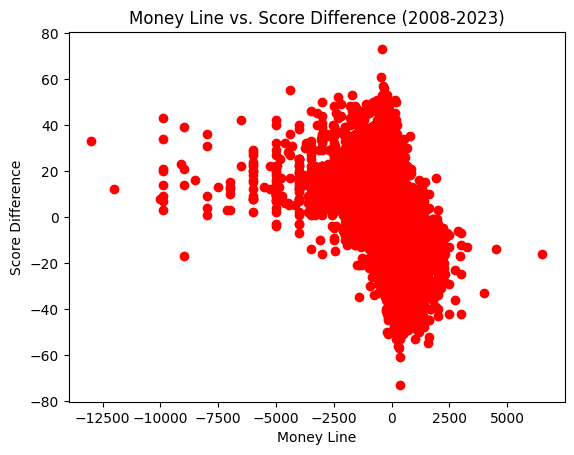

In [3]:
score_difference = odd_data["score"] - odd_data["opponentScore"]
money_line = odd_data["moneyLine"]
plt.scatter(money_line, score_difference, color= "red")
plt.xlabel("Money Line")
plt.ylabel("Score Difference")
plt.title("Money Line vs. Score Difference (2008-2023)")

In [4]:
corr = scipy.stats.pearsonr(money_line, score_difference)
print(corr)
print(corr[0])
correlation_score = corr [0]
print(correlation_score)

PearsonRResult(statistic=np.float64(-0.39335288766190873), pvalue=np.float64(0.0))
-0.39335288766190873
-0.39335288766190873


In [5]:
## This game answers the question of: whether the money line (betting odds) predicts how much a team wins or loses by? My interpretation of these results is that the moneyline is correct in favoring what team will win more often than not. There a few outlier like the most right red dot and the lowest dot but they just show how random things can happen in NBA Games


In [6]:
nba_data = pd.read_csv("oddsData.csv")

([<matplotlib.axis.YTick at 0x12ebac220>,
 [Text(0, 0, 'season'),
  Text(0, 1, 'score'),
  Text(0, 2, 'opponentScore'),
  Text(0, 3, 'moneyLine'),
  Text(0, 4, 'opponentMoneyLine'),
  Text(0, 5, 'total'),
  Text(0, 6, 'spread'),
  Text(0, 7, 'secondHalfTotal')])

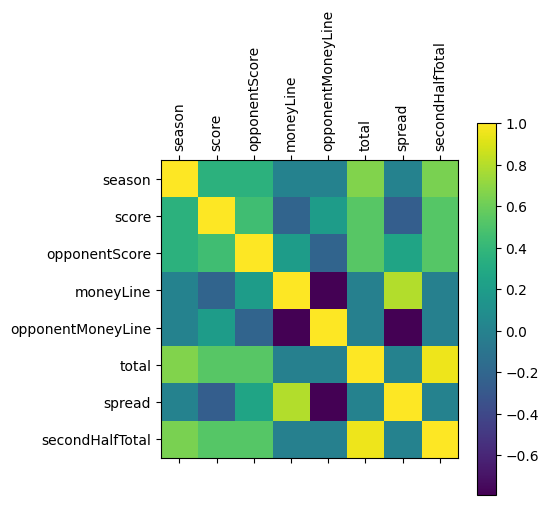

In [7]:
corr_scores = nba_data.corr(numeric_only = True)
plt.matshow(corr_scores)
plt.colorbar()
n = len(corr_scores.index)
plt.xticks (ticks= range(n), labels = corr_scores.index, rotation = 90)
plt.yticks (ticks = range(n), labels = corr_scores.index)

In [11]:
nba_data["win"] = (nba_data["score"] > nba_data["opponentScore"]).astype(int)
features = ["moneyLine", "opponentMoneyLine", "spread", "total", "secondHalfTotal"]
X = nba_data[features]
y = nba_data["win"] 
## The Win column is already formated for classification because I just took categories and used them together to form a new integer.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Accuracy 0.626734941382563


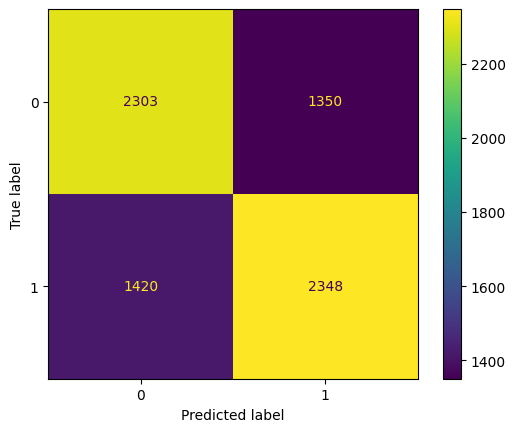

In [12]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
accuracy = accuracy_score(predictions, y_test)
print("Accuracy", accuracy)
ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)

In [13]:
odd_data = pd.read_csv("oddsdata.csv")
print(odd_data)

             date  season          team home/visitor      opponent  score  \
0      2007-10-30    2008          Utah            @  Golden State    117   
1      2007-10-30    2008     LA Lakers           vs       Houston     93   
2      2007-10-30    2008       Houston            @     LA Lakers     95   
3      2007-10-30    2008   San Antonio           vs      Portland    106   
4      2007-10-30    2008      Portland            @   San Antonio     97   
...           ...     ...           ...          ...           ...    ...   
37099  2023-01-16    2023       Toronto            @      New York    123   
37100  2023-01-16    2023       Memphis           vs       Phoenix    136   
37101  2023-01-16    2023      New York           vs       Toronto    121   
37102  2023-01-16    2023     Minnesota           vs          Utah    125   
37103  2023-01-16    2023  Golden State            @    Washington    127   

       opponentScore  moneyLine  opponentMoneyLine  total  spread  \
0     

In [14]:
odd_data.describe()

,season,score,opponentScore,moneyLine,opponentMoneyLine,total,spread,secondHalfTotal
count,37104.000000,37104.000000,37104.000000,37104.000000,37104.000000,37104.000000,37104.000000,37104.000000
mean,2015.230649,104.031883,104.031883,-66.172124,-66.172124,207.662867,0.000000,103.125129
std,4.490420,13.298384,13.298384,605.354444,605.354444,14.279420,7.117256,7.028944
min,2008.000000,54.000000,54.000000,-13000.000000,-13000.000000,170.500000,-21.500000,84.000000
25%,2011.000000,95.000000,95.000000,-240.000000,-240.000000,196.000000,-5.500000,97.500000
50%,2015.000000,104.000000,104.000000,-110.000000,-110.000000,207.000000,0.000000,103.000000
75%,2019.000000,113.000000,113.000000,195.000000,195.000000,218.500000,5.500000,108.000000
max,2023.000000,168.000000,168.000000,6500.000000,6500.000000,251.000000,21.500000,125.000000


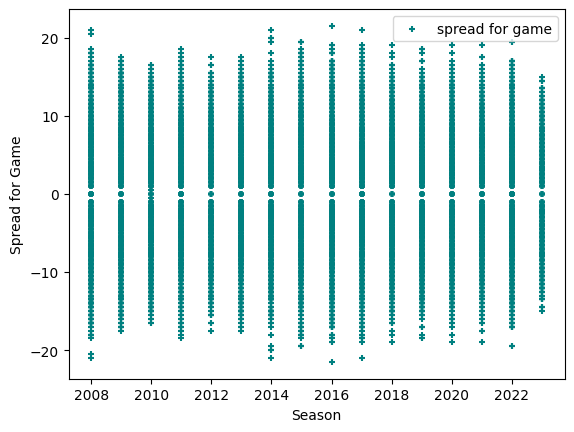

In [15]:
spread= odd_data["spread"]
season = odd_data["season"]
plt.scatter(season, spread, color= "teal", marker = "+", s=15,label = "spread for game")
plt.xlabel("Season")
plt.ylabel("Spread for Game")
plt.legend()

In [16]:
corr = scipy.stats.pearsonr(season, spread)
print(corr)
print(corr[0])
correlation_score = corr [0]
print(correlation_score)

PearsonRResult(statistic=np.float64(-4.336808689942018e-19), pvalue=np.float64(0.9999999999999993))
-4.336808689942018e-19
-4.336808689942018e-19
